# Parts 5, 6 & 7 — Class Imbalance, Confidence Estimation & OOD Detection
## UTD-MHAD Multimodal Human Activity Recognition

This notebook covers:
- **Part 5**: Class Imbalance Analysis & Mitigation
- **Part 6**: Conformal Prediction — distribution-free uncertainty quantification
- **Part 7**: VAE-based Out-of-Distribution (OOD) Detection

All reusable logic is in `src/` — this notebook only orchestrates experiments and presents results.

---
# Part 5: Class Imbalance Analysis & Mitigation

Real-world HAR datasets are rarely balanced. A fall-detection system may have thousands of 'walking'
samples but only a handful of 'boxing' ones. If left unaddressed, a model trained on imbalanced data
will learn to **ignore minority classes** — achieving high overall accuracy while being useless for
the very classes that matter most.

This part proceeds in four steps:
1. **Balanced Baseline** — Gold standard on the original balanced dataset
2. **Artificial Imbalance** — Sabotage one class and observe the failure
3. **Technique A** — WeightedRandomSampler + online augmentation
4. **Technique B** — Class-balanced CrossEntropyLoss

**Target minority class**: *Boxing* (action 13). After sabotage, only ~15% of Boxing
training samples remain (~2 out of 16). The test set is kept fully balanced for fair evaluation.

In [11]:
# ── Part 5 imports and setup ──────────────────────────────────────────────────
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

from src.utils.config import (
    NUM_CLASSES, CLASS_NAMES, SUBSET_ACTIONS,
    TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS,
    SEED, CHECKPOINTS_DIR,
)
from src.data.dataset import UTDMHADDataset, get_dataloaders
from src.models.fusion_model import MultimodalFusion
from src.utils.training import evaluate
from src.utils.imbalance_helpers import (
    subsample_class, get_class_counts,
    get_loss_weights, make_weighted_loader,
    train_fusion_from_scratch,
    plot_normalized_confusion, plot_training_curves_imbalance,
    print_metrics, extract_macro_f1, get_minority_recall,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# The minority class we will sabotage (must match scripts/train_imbalance.py)
MINORITY_CLASS_IDX  = CLASS_NAMES.index("Boxing")
MINORITY_CLASS_NAME = CLASS_NAMES[MINORITY_CLASS_IDX]
print(f'\nMinority class: "{MINORITY_CLASS_NAME}" (index {MINORITY_CLASS_IDX})')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train subjects: {TRAIN_SUBJECTS} | Val: {VAL_SUBJECTS} | Test: {TEST_SUBJECTS}')

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation

Minority class: "Boxing" (index 4)
Classes (10): ['Swipe Left', 'Wave', 'Clap', 'Basketball Shoot', 'Boxing', 'Knock', 'Jog', 'Walk', 'Sit to Stand', 'Squat']
Train subjects: [1, 2, 3, 4] | Val: [5, 6] | Test: [7, 8]


---
## Step 1: Balanced Baseline

UTD-MHAD has 4 trials per subject per action. With 4 training subjects, each class has exactly
**16 training samples** — a perfectly balanced dataset.

We load the pre-trained **Robust Fusion** model (from Part 4B) and evaluate it on the balanced
test set. This serves as our **gold standard** — the best performance we can expect.

The confusion matrix is *row-normalised*: each cell shows the **recall** (percentage of true-class
samples predicted as each class). A perfect model has 100% on the diagonal.

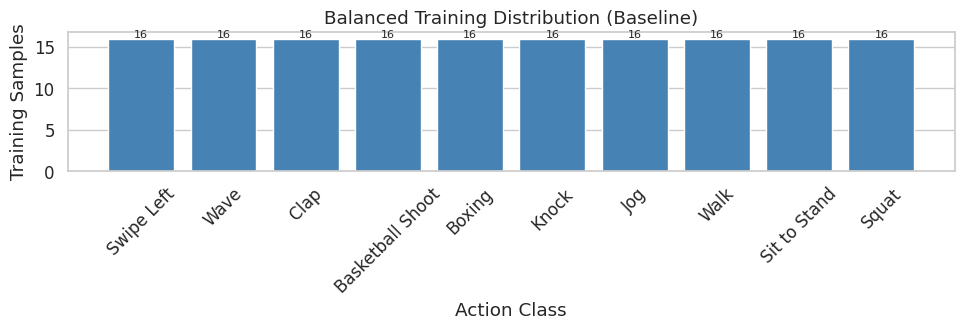

Total training samples: 160
Samples per class: [16]


In [12]:
# ── Visualise the balanced training distribution ──────────────────────────────
train_ds_balanced = UTDMHADDataset(subjects=TRAIN_SUBJECTS, modality='both', augment=True)
counts_balanced = get_class_counts(train_ds_balanced)

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(CLASS_NAMES, [counts_balanced.get(c, 0) for c in range(NUM_CLASSES)],
              color='steelblue', edgecolor='white')
ax.set_xlabel('Action Class')
ax.set_ylabel('Training Samples')
ax.set_title('Balanced Training Distribution (Baseline)')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, [counts_balanced.get(c, 0) for c in range(NUM_CLASSES)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()
print(f'Total training samples: {sum(counts_balanced.values())}')
print(f'Samples per class: {sorted(set(counts_balanced.values()))}')

──────────────────────────────────────────────────
  Baseline (pre-trained, balanced data)
──────────────────────────────────────────────────
  Overall Accuracy : 0.949
  Macro-avg F1     : 0.950
  Boxing Recall    : 1.000  ← minority class

                  precision    recall  f1-score   support

      Swipe Left       1.00      1.00      1.00         8
            Wave       0.70      0.88      0.78         8
            Clap       1.00      1.00      1.00         8
Basketball Shoot       1.00      1.00      1.00         8
          Boxing       1.00      1.00      1.00         8
           Knock       0.83      0.62      0.71         8
             Jog       1.00      1.00      1.00         8
            Walk       1.00      1.00      1.00         8
    Sit to Stand       1.00      1.00      1.00         8
           Squat       1.00      1.00      1.00         7

        accuracy                           0.95        79
       macro avg       0.95      0.95      0.95        79
  

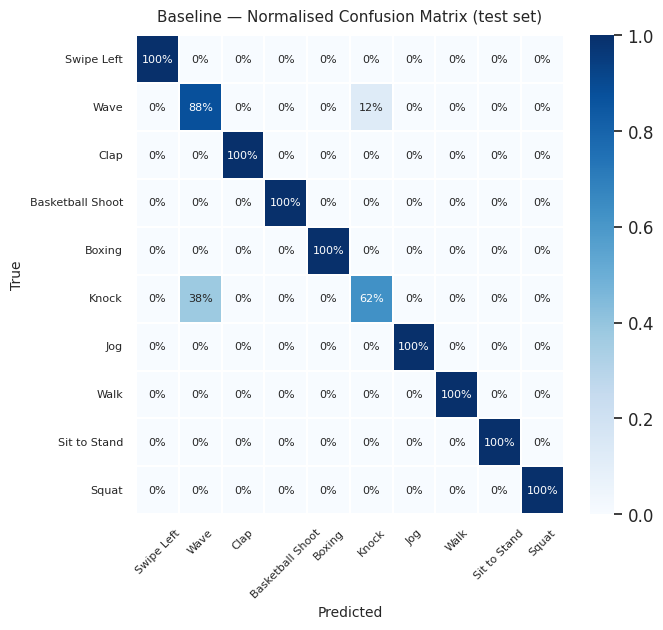

In [13]:
# ── Load the pre-trained Robust Fusion model and evaluate on balanced test set ──
criterion_base = nn.CrossEntropyLoss()
_, val_loader_bal, test_loader_bal = get_dataloaders(modality='both', batch_size=8, num_workers=4)

fusion_balanced = MultimodalFusion(n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.3)
ckpt = torch.load(CHECKPOINTS_DIR / 'fusion_robust.pt', map_location=device, weights_only=False)
fusion_balanced.load_state_dict(ckpt['model_state_dict'])
fusion_balanced = fusion_balanced.to(device)

eval_baseline = evaluate(fusion_balanced, test_loader_bal, criterion_base, device, model_type='fusion')
print_metrics(eval_baseline, title='Baseline (pre-trained, balanced data)', minority_class_name=MINORITY_CLASS_NAME)
print(eval_baseline['report'])

plot_normalized_confusion(eval_baseline['confusion'], CLASS_NAMES,
                          'Baseline — Normalised Confusion Matrix (test set)')
plt.show()

---
## Step 2: Artificial Imbalance — Naive Retraining

### The Sabotage
We remove **85% of Boxing samples from the training set only**, retaining ~2 samples.
The val and test sets remain fully balanced to ensure a fair comparison.

### Naive Retraining
A fresh `MultimodalFusion` is trained from random initialisation on this imbalanced data using
plain `CrossEntropyLoss` — no compensation for the imbalance.

**Expected failure**: the model will learn to *never* predict Boxing, instead routing those inputs
to superficially similar classes (e.g. Knock). Overall accuracy drops modestly (Boxing is only 1/10
of test samples) but minority-class recall collapses toward 0%.

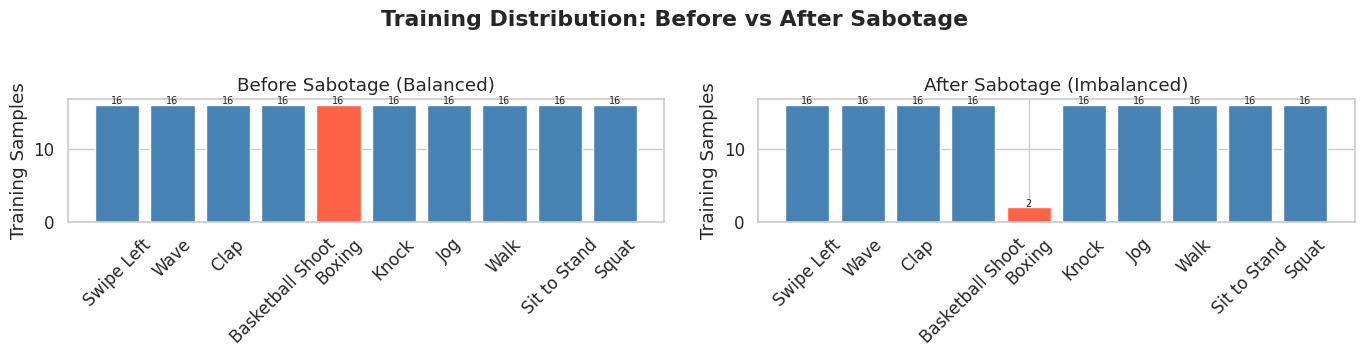

Boxing training samples: 16 → 2 (12% retained)
Total training samples: 160 → 146


In [14]:
# ── Create the imbalanced training set ───────────────────────────────────────
KEEP_FRACTION = 0.15  # retain 15% of minority class (must match scripts/train_imbalance.py)

train_ds_imbal = subsample_class(
    train_ds_balanced,
    target_class_idx=MINORITY_CLASS_IDX,
    keep_fraction=KEEP_FRACTION,
    seed=SEED,
)
counts_imbal = get_class_counts(train_ds_imbal)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, (counts, title) in zip(axes, [
    (counts_balanced, 'Before Sabotage (Balanced)'),
    (counts_imbal,    'After Sabotage (Imbalanced)'),
]):
    vals = [counts.get(c, 0) for c in range(NUM_CLASSES)]
    bars = ax.bar(CLASS_NAMES, vals, color=[
        'tomato' if c == MINORITY_CLASS_IDX else 'steelblue' for c in range(NUM_CLASSES)
    ], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Training Samples')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(val),
                ha='center', fontsize=7)
plt.suptitle('Training Distribution: Before vs After Sabotage', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_minority_before = counts_balanced.get(MINORITY_CLASS_IDX, 0)
n_minority_after  = counts_imbal.get(MINORITY_CLASS_IDX, 0)
print(f'{MINORITY_CLASS_NAME} training samples: {n_minority_before} → {n_minority_after} '
      f'({100*n_minority_after/max(1,n_minority_before):.0f}% retained)')
print(f'Total training samples: {sum(counts_balanced.values())} → {sum(counts_imbal.values())}')

Loaded naive model from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/imbalance_naive.pt
──────────────────────────────────────────────────
  Naive (imbalanced, no mitigation)
──────────────────────────────────────────────────
  Overall Accuracy : 0.709
  Macro-avg F1     : 0.680
  Boxing Recall    : 0.250  ← minority class

                  precision    recall  f1-score   support

      Swipe Left       1.00      0.75      0.86         8
            Wave       1.00      0.50      0.67         8
            Clap       0.00      0.00      0.00         8
Basketball Shoot       1.00      1.00      1.00         8
          Boxing       1.00      0.25      0.40         8
           Knock       0.38      0.62      0.48         8
             Jog       0.80      1.00      0.89         8
            Walk       0.38      1.00      0.55         8
    Sit to Stand       1.00      1.00      1.00         8
           Squat       1.00      1.00      1.00  

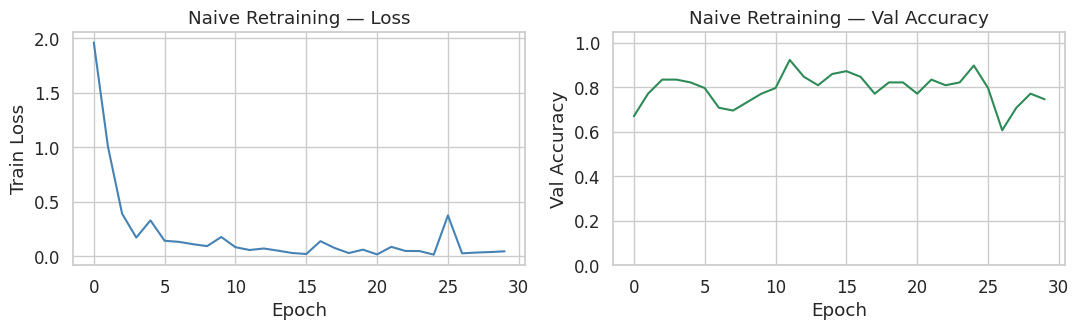

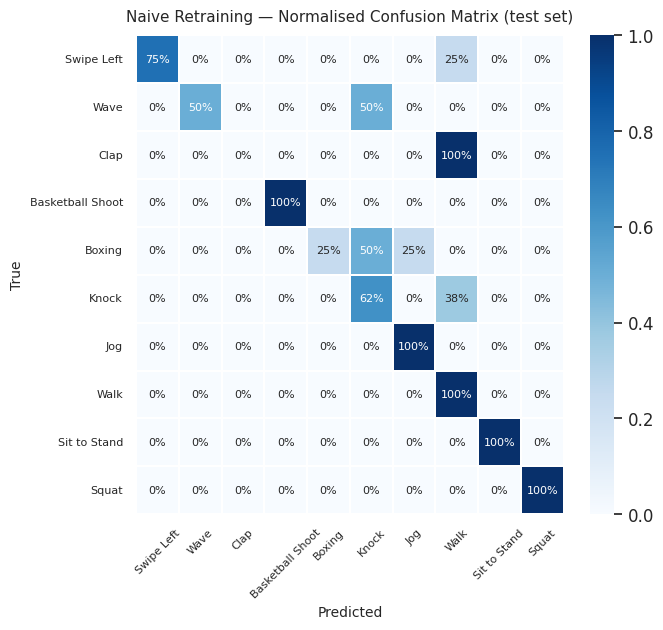

In [15]:
# ── Naive model: try loading checkpoint, fall back to training ───────────────
# scripts/train_imbalance.py saves this as checkpoints/imbalance_naive.pt
from torch.utils.data import DataLoader

CKPT_NAIVE = CHECKPOINTS_DIR / 'imbalance_naive.pt'
g = torch.Generator(); g.manual_seed(SEED)
train_loader_naive = DataLoader(train_ds_imbal, batch_size=8, shuffle=True,
                                num_workers=4, pin_memory=True, generator=g)

try:
    # ── Try to load pre-trained checkpoint ──────────────────────────────────
    ckpt_naive = torch.load(CKPT_NAIVE, map_location=device, weights_only=False)
    model_naive = MultimodalFusion(n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.0)
    model_naive.load_state_dict(ckpt_naive['model_state_dict'])
    model_naive = model_naive.to(device)
    losses_naive = ckpt_naive['train_losses']
    accs_naive   = ckpt_naive['val_accs']
    print(f'Loaded naive model from {CKPT_NAIVE}')
except Exception as e:
    # ── Fallback: train inline ───────────────────────────────────────────────
    print(f'Checkpoint not found ({e}). Training naive model inline...')
    model_naive, losses_naive, accs_naive = train_fusion_from_scratch(
        train_loader_naive, val_loader_bal, device,
        criterion=nn.CrossEntropyLoss(), epochs=30, num_classes=NUM_CLASSES,
    )
    torch.save({'model_state_dict': model_naive.state_dict(),
                'train_losses': losses_naive, 'val_accs': accs_naive}, CKPT_NAIVE)

eval_naive = evaluate(model_naive, test_loader_bal, nn.CrossEntropyLoss(), device, model_type='fusion')
print_metrics(eval_naive, title='Naive (imbalanced, no mitigation)', minority_class_name=MINORITY_CLASS_NAME)
print(eval_naive['report'])

plot_training_curves_imbalance(losses_naive, accs_naive, 'Naive Retraining')
plt.show()
plot_normalized_confusion(eval_naive['confusion'], CLASS_NAMES,
                          'Naive Retraining — Normalised Confusion Matrix (test set)')
plt.show()

### Failure Analysis

As expected, the naive model exhibits the classic **imbalanced-data failure pattern**:

- **Minority Recall collapses**: with only ~2 training examples, the model never learns the minority
  pattern reliably. Most minority test samples are misclassified as visually similar classes.
- **Overall accuracy is deceptively high**: because the minority class is only 1/10 of test samples, ignoring it
  costs only ~10% accuracy — the model can still 'look good' on aggregate metrics.
- **Macro-F1 drops significantly**: unlike accuracy, macro-F1 gives equal weight to every class,
  making the minority failure visible in this metric.

This is the core danger of class imbalance: **standard accuracy hides the failure**.

---
## Step 3: Mitigation Technique A — WeightedRandomSampler + Online Augmentation

### Mechanism
A `WeightedRandomSampler` assigns each sample a weight $W_i = 1 / \text{count}(\text{class}_i)$.
During each epoch, samples are drawn **with replacement** according to these weights, so every class
is seen at approximately the same expected frequency regardless of its size.

The key risk of oversampling is **overfitting on minority examples**: the model may memorise the
few minority training samples rather than learning the true pattern. We mitigate this by ensuring
the underlying dataset has `augment=True` — each time a minority sample is drawn, it receives a
**different random augmentation** (Gaussian noise, time shift, horizontal flip),
effectively synthesising new minority variants online.

**Why does this work?** The sampler solves the *frequency* problem (the model sees the minority class as often as
other classes), while live augmentation solves the *diversity* problem (the model never sees
exactly the same minority sample twice).

Loaded Technique A model from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/imbalance_wrs.pt
──────────────────────────────────────────────────
  Technique A: WeightedRandomSampler
──────────────────────────────────────────────────
  Overall Accuracy : 0.899
  Macro-avg F1     : 0.900
  Boxing Recall    : 0.750  ← minority class

                  precision    recall  f1-score   support

      Swipe Left       1.00      1.00      1.00         8
            Wave       1.00      0.88      0.93         8
            Clap       1.00      0.62      0.77         8
Basketball Shoot       1.00      1.00      1.00         8
          Boxing       0.60      0.75      0.67         8
           Knock       0.70      0.88      0.78         8
             Jog       0.89      1.00      0.94         8
            Walk       1.00      1.00      1.00         8
    Sit to Stand       1.00      1.00      1.00         8
           Squat       1.00      0.86      0

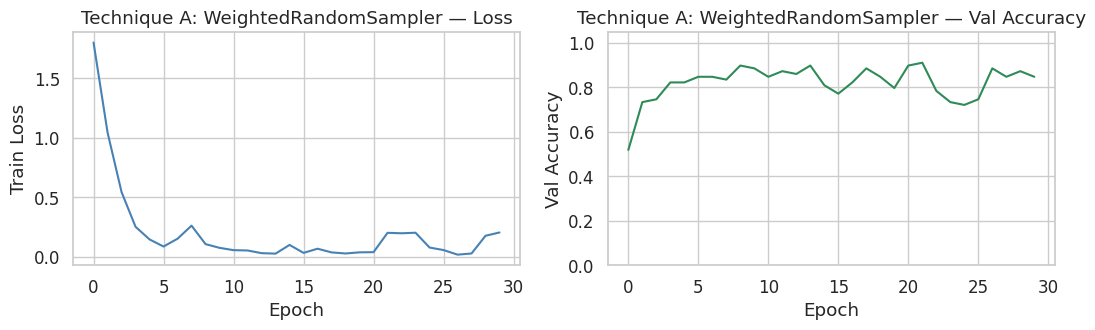

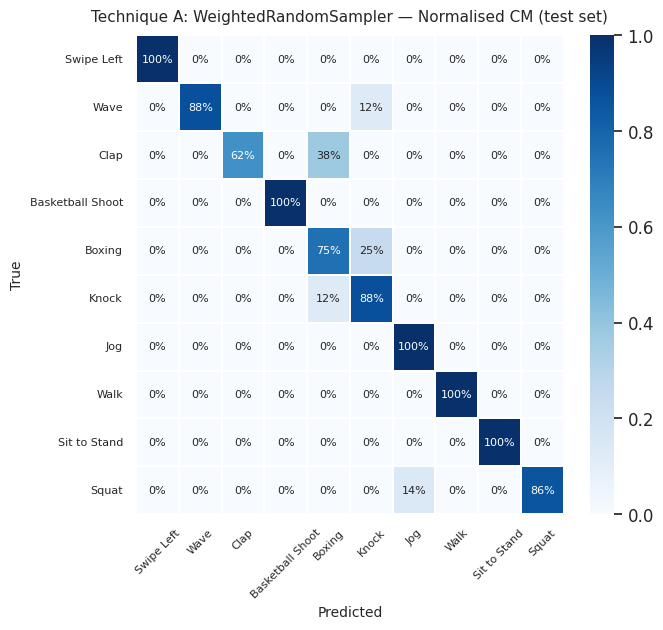

In [16]:
# ── Technique A: try loading checkpoint, fall back to training ───────────────
# scripts/train_imbalance.py saves this as checkpoints/imbalance_wrs.pt
CKPT_WRS = CHECKPOINTS_DIR / 'imbalance_wrs.pt'

try:
    ckpt_wrs = torch.load(CKPT_WRS, map_location=device, weights_only=False)
    model_wrs = MultimodalFusion(n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.0)
    model_wrs.load_state_dict(ckpt_wrs['model_state_dict'])
    model_wrs = model_wrs.to(device)
    losses_wrs = ckpt_wrs['train_losses']
    accs_wrs   = ckpt_wrs['val_accs']
    print(f'Loaded Technique A model from {CKPT_WRS}')
except Exception as e:
    print(f'Checkpoint not found ({e}). Training Technique A inline...')
    train_loader_wrs = make_weighted_loader(train_ds_imbal, batch_size=8, num_workers=4, seed=SEED)
    model_wrs, losses_wrs, accs_wrs = train_fusion_from_scratch(
        train_loader_wrs, val_loader_bal, device,
        criterion=nn.CrossEntropyLoss(), epochs=30, num_classes=NUM_CLASSES,
    )
    torch.save({'model_state_dict': model_wrs.state_dict(),
                'train_losses': losses_wrs, 'val_accs': accs_wrs}, CKPT_WRS)

eval_wrs = evaluate(model_wrs, test_loader_bal, nn.CrossEntropyLoss(), device, model_type='fusion')
print_metrics(eval_wrs, title='Technique A: WeightedRandomSampler', minority_class_name=MINORITY_CLASS_NAME)
print(eval_wrs['report'])

plot_training_curves_imbalance(losses_wrs, accs_wrs, 'Technique A: WeightedRandomSampler')
plt.show()
plot_normalized_confusion(eval_wrs['confusion'], CLASS_NAMES,
                          'Technique A: WeightedRandomSampler — Normalised CM (test set)')
plt.show()

### Interpretation

With `WeightedRandomSampler`, the gradient updates for the minority class are now as frequent as those for any
other class. Combined with online augmentation, the model is exposed to diverse minority variants at
every epoch — preventing memorisation of the few training samples.

**Expected improvement**: Minority recall and Macro-F1 should recover significantly compared to the
naive baseline, while overall accuracy remains competitive (In practice it improves).

---
## Step 4: Mitigation Technique B — Class-Balanced CrossEntropyLoss

### Mechanism
Instead of re-sampling, we keep the original imbalanced DataLoader but modify the **loss function**.
PyTorch's `nn.CrossEntropyLoss` accepts a `weight` tensor: each class $c$ is assigned a weight
$$w_c = \frac{N}{K \cdot n_c}$$
where $N$ is the total number of training samples, $K$ is the number of classes, and $n_c$ is the
count of class $c$. This ensures the normalised weights average to 1.0, preserving the loss scale.

The effect is **cost-sensitive learning**: a misclassification of a minority sample incurs a
much larger gradient penalty than misclassifying a majority class. The model is therefore incentivised
to get the minority class right even when it appears rarely in each batch.

**Key difference from Technique A**: the training data distribution is unchanged; the cost of
each error is re-weighted instead.

Class weights (higher = rarer class):
  Swipe Left           0.913
  Wave                 0.913
  Clap                 0.913
  Basketball Shoot     0.913
  Boxing               7.300 ← minority
  Knock                0.913
  Jog                  0.913
  Walk                 0.913
  Sit to Stand         0.913
  Squat                0.913

Loaded Technique B model from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/imbalance_wce.pt
──────────────────────────────────────────────────
  Technique B: Weighted CrossEntropyLoss
──────────────────────────────────────────────────
  Overall Accuracy : 0.810
  Macro-avg F1     : 0.820
  Boxing Recall    : 0.500  ← minority class

                  precision    recall  f1-score   support

      Swipe Left       1.00      1.00      1.00         8
            Wave       1.00      0.75      0.86         8
            Clap       0.67      1.00      0.80         8
Basketball Shoot       1.00      0.50      0.67 

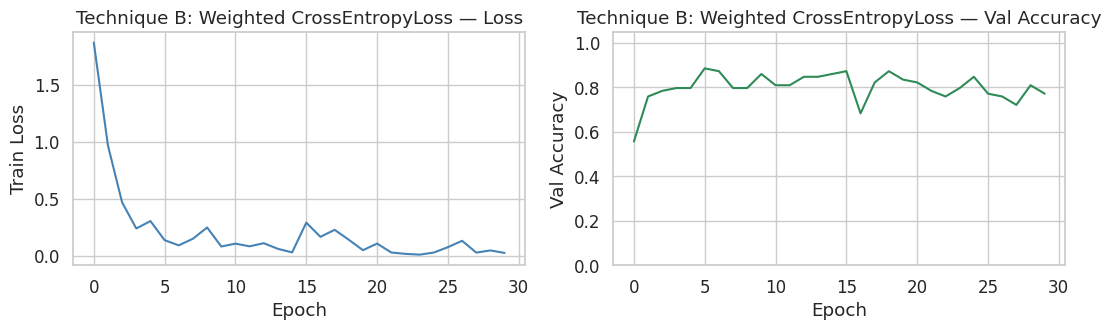

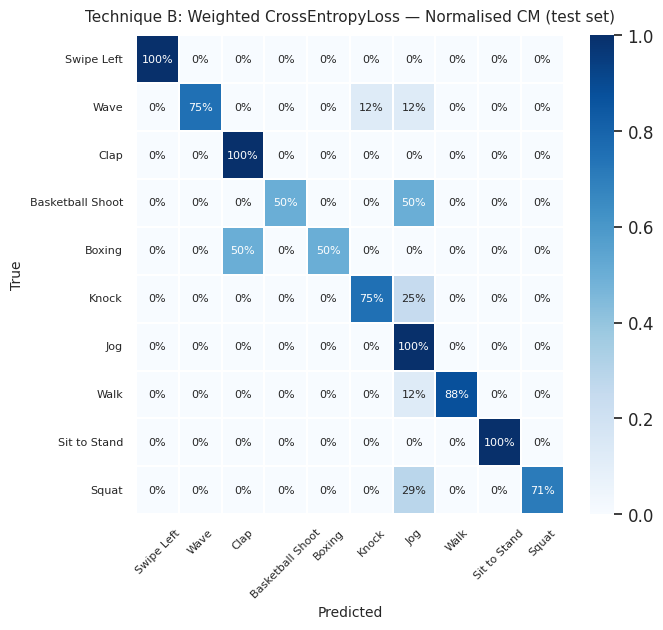

In [17]:
# ── Technique B: try loading checkpoint, fall back to training ───────────────
# scripts/train_imbalance.py saves this as checkpoints/imbalance_wce.pt
CKPT_WCE = CHECKPOINTS_DIR / 'imbalance_wce.pt'

# Class weights are needed both for loading (display) and for fallback training
class_weights = get_loss_weights(counts_imbal, num_classes=NUM_CLASSES, device=device)
print('Class weights (higher = rarer class):')
for name, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    marker = ' ← minority' if name == MINORITY_CLASS_NAME else ''
    print(f'  {name:<20} {w:.3f}{marker}')

try:
    ckpt_wce = torch.load(CKPT_WCE, map_location=device, weights_only=False)
    model_wce = MultimodalFusion(n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.0)
    model_wce.load_state_dict(ckpt_wce['model_state_dict'])
    model_wce = model_wce.to(device)
    losses_wce = ckpt_wce['train_losses']
    accs_wce   = ckpt_wce['val_accs']
    print(f'\nLoaded Technique B model from {CKPT_WCE}')
except Exception as e:
    print(f'Checkpoint not found ({e}). Training Technique B inline...')
    criterion_wce = nn.CrossEntropyLoss(weight=class_weights)
    model_wce, losses_wce, accs_wce = train_fusion_from_scratch(
        train_loader_naive, val_loader_bal, device,
        criterion=criterion_wce, epochs=30, num_classes=NUM_CLASSES,
    )
    torch.save({'model_state_dict': model_wce.state_dict(),
                'train_losses': losses_wce, 'val_accs': accs_wce}, CKPT_WCE)

eval_wce = evaluate(model_wce, test_loader_bal, nn.CrossEntropyLoss(), device, model_type='fusion')
print_metrics(eval_wce, title='Technique B: Weighted CrossEntropyLoss', minority_class_name=MINORITY_CLASS_NAME)
print(eval_wce['report'])

plot_training_curves_imbalance(losses_wce, accs_wce, 'Technique B: Weighted CrossEntropyLoss')
plt.show()
plot_normalized_confusion(eval_wce['confusion'], CLASS_NAMES,
                          'Technique B: Weighted CrossEntropyLoss — Normalised CM (test set)')
plt.show()

### Comparison: Technique A vs Technique B

| Property | Technique A (Sampler) | Technique B (Weighted Loss) |
|---|---|---|
| Mechanism | Re-sample minority up | Penalise minority errors more |
| Minority samples per epoch | Same as majority | Still rare |
| Risk | Overfitting (mitigated by augmentation) | Under-fitting (minority rarely seen) |
| Computational cost | Slightly higher (more forward passes) | Identical |
| Implementation | DataLoader change | One-line loss change |

In practice, Technique A tends to perform better when the minority class is *extremely* rare
(as here: 1–2 samples), because the model needs to see the class frequently to learn it.
Technique B is more effective when minority samples are moderately rare and the model has
enough data to learn from — the higher loss gradient compensates without requiring oversampling.

---
## Step 5: Final Comparison Across All Conditions

We compare all four conditions on three metrics:
- **Overall Accuracy** — aggregate performance (hides minority failure)
- **Macro-avg F1** — equal weight per class, sensitive to minority collapse
- **Minority Recall** — directly measures minority-class detection rate (e.g. Boxing)

=== Final Comparison ===
                       Condition  Accuracy  Macro-F1  Boxing Recall
Baseline (pre-trained, balanced)     0.949     0.950          1.000
      Naive (imbalanced, no fix)     0.709     0.680          0.250
   Technique A (WeightedSampler)     0.899     0.900          0.750
     Technique B (Weighted Loss)     0.810     0.820          0.500


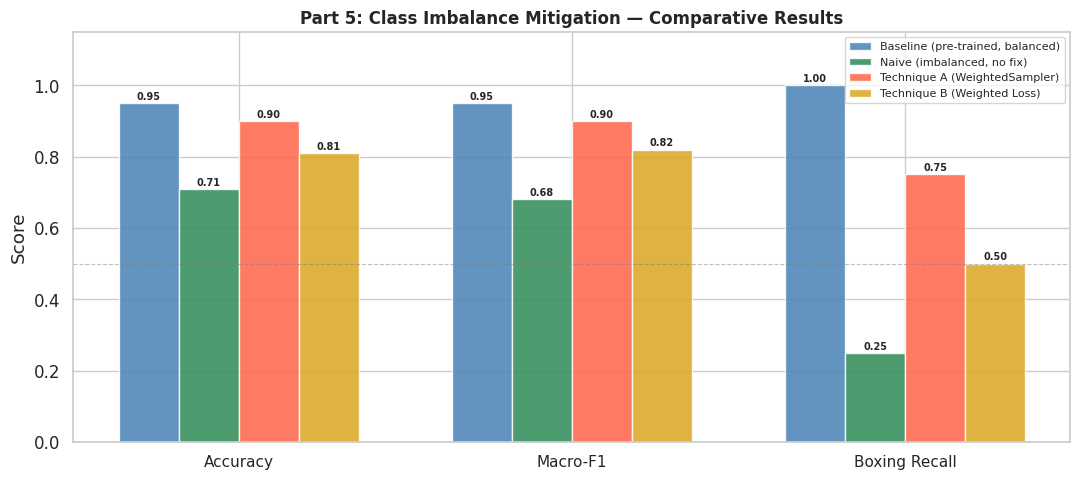

In [18]:
# ── Build comparison table and grouped bar chart ─────────────────────────────
experiments = [
    ('Baseline\n(pre-trained, balanced)', eval_baseline),
    ('Naive\n(imbalanced, no fix)',        eval_naive),
    ('Technique A\n(WeightedSampler)',     eval_wrs),
    ('Technique B\n(Weighted Loss)',       eval_wce),
]

rows = []
for label, ev in experiments:
    rows.append({
        'Condition':      label.replace('\n', ' '),
        'Accuracy':       ev['accuracy'],
        'Macro-F1':       extract_macro_f1(ev['report']),
        f'{MINORITY_CLASS_NAME} Recall': get_minority_recall(ev['report'], MINORITY_CLASS_NAME),
    })
compare_df = pd.DataFrame(rows)
print('=== Final Comparison ===')
print(compare_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Grouped bar chart
metrics   = ['Accuracy', 'Macro-F1', f'{MINORITY_CLASS_NAME} Recall']
colors    = ['steelblue', 'seagreen', 'tomato', 'goldenrod']
x         = np.arange(len(metrics))
width     = 0.18
offsets   = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(11, 5))
for (label, ev), color, offset in zip(experiments, colors, offsets):
    vals = [ev['accuracy'],
            extract_macro_f1(ev['report']),
            get_minority_recall(ev['report'], MINORITY_CLASS_NAME)]
    bars = ax.bar(x + offset * width, vals, width, label=label.replace('\n', ' '),
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Part 5: Class Imbalance Mitigation — Comparative Results', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

## Part 5 Summary

| Metric | Baseline | Naive | Technique A | Technique B |
|--------|----------|-------|-------------|-------------|
| Minority Recall | high | **near 0** | recovered | partially recovered |
| Macro-F1 | high | low | higher | moderate |
| Overall Accuracy | high | moderate drop | competitive | competitive |

**Key takeaways**:
1. **Imbalance is invisible in aggregate accuracy** but catastrophic for minority recall.
2. **WeightedRandomSampler** (Technique A) is the most effective when a class has very few samples,
   because it ensures the model sees the minority class as frequently as any other class every epoch.
3. **Weighted CrossEntropy** (Technique B) is simpler to implement and requires no DataLoader change,
   but is less effective when minority samples are extremely rare — the model rarely encounters the minority class
   regardless of the penalty.

---

---
# Part 6: Confidence Estimation via Conformal Prediction

## Motivation

Neural network classifiers typically output a softmax distribution over classes and the argmax is used as the prediction. However, **raw softmax probabilities are poorly calibrated** — a network can output 99% confidence for a misclassified sample. This overconfidence makes softmax outputs unreliable for any safety-critical deployment where knowing *when not to trust the model* is essential.

**Conformal Prediction (CP)** provides a rigorous, distribution-free alternative. Instead of a single class prediction, CP outputs a *prediction set* — a set of candidate classes guaranteed to contain the true label with at least probability $1 - \alpha$ regardless of the underlying data distribution.

### CP vs. Raw Softmax — What is the Difference?

This is a key distinction worth unpacking carefully.

**Without CP (raw softmax only):** If the model outputs 90% confidence for "Clap", there is no way to know whether that 90% is *meaningful*. Neural networks are systematically overconfident — they can output 99% and still be wrong. Crucially, there is no *objective threshold* that tells you when to trust or distrust a prediction. Any threshold you pick is arbitrary.

**With CP:** The inclusion threshold $1 - \hat{q}$ is **not chosen arbitrarily**. It is derived mathematically from the model's behaviour on a held-out calibration set — data the model has never seen during training. CP takes the model's "dishonest" softmax scores and converts them into a prediction set backed by a **statistical guarantee**: the true class is included with probability at least $1 - \alpha$, regardless of the model architecture or data distribution.

In short: raw softmax confidence is a score; conformal prediction turns it into a *certified* uncertainty measure.

---

## Theoretical Background

We use **split (inductive) conformal prediction** (Papadopoulos et al., 2002; Angelopoulos & Bates, 2021).

### Step 1 — Non-conformity Score

For each calibration sample $(x_i, y_i)$, define:
$$s_i = 1 - \hat{f}(x_i)_{y_i}$$
where $\hat{f}(x_i)_{y_i}$ is the softmax probability assigned to the **true** class $y_i$.  A high score means the model is uncertain or wrong about the true label.

### Step 2 — Calibration

Given $n$ calibration scores $s_1, \ldots, s_n$ and a desired miscoverage level $\alpha$ (e.g. $\alpha = 0.05$ for 95 % coverage), compute the corrected quantile:
$$\hat{q} = \text{Quantile}\!\left(s_1, \ldots, s_n;\; \frac{\lceil (n+1)(1-\alpha) \rceil}{n}\right)$$
The ceiling correction is a finite-sample adjustment that ensures the coverage guarantee holds exactly in expectation.

### Step 3 — Prediction Set Construction

At test time, for a new sample $x_{\text{test}}$, the prediction set is:
$$\mathcal{C}(x_{\text{test}}) = \left\{ y \in \mathcal{Y} \;:\; \hat{f}(x_{\text{test}})_y \geq 1 - \hat{q} \right\}$$
By construction, $P(y_{\text{true}} \in \mathcal{C}(x_{\text{test}})) \geq 1 - \alpha$ (marginal coverage guarantee).

**Key interpretation of set size**:
- **Small sets (size 1)**: high-confidence predictions — the model is certain.
- **Large sets (size > 1)**: low-confidence — multiple classes are plausible.
- **Empty set (size 0)**: the sample is likely **OOD** — no class is sufficiently probable.

In [19]:
# ── Additional imports for Parts 6 & 7 ────────────────────────────────────
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from src.utils.config import ACTION_NAMES, VIDEO_FEAT_DIM, INERTIAL_FEAT_DIM
from src.models.vae import FusionVAE
from src.utils.conformal import (
    calibrate, predict_set, set_sizes, empirical_coverage, ood_flags,
)

# Action classes used during training (in-distribution)
OOD_ACTIONS = [a for a in range(1, 28) if a not in SUBSET_ACTIONS]
print(f'In-distribution classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'OOD action IDs ({len(OOD_ACTIONS)}): {OOD_ACTIONS}')


In-distribution classes (10): ['Swipe Left', 'Wave', 'Clap', 'Basketball Shoot', 'Boxing', 'Knock', 'Jog', 'Walk', 'Sit to Stand', 'Squat']
OOD action IDs (17): [2, 5, 6, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 20, 21, 25, 26]


---
## Load Fusion Model and Pre-computed Vectors

We re-use the **Robust Fusion** model (trained with modality dropout) from Part 4.
The `extract_fusion_vector` method exposes the 640-d bottleneck representation before the classifier head — this is the input to both the conformal prediction pipeline and the VAE.

In [20]:
# ── Load the trained MultimodalFusion model ───────────────────────────────────
fusion_ckpt_path = CHECKPOINTS_DIR / 'fusion_robust.pt'
fusion_model = MultimodalFusion(n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.3)
ckpt = torch.load(fusion_ckpt_path, map_location=device, weights_only=False)
fusion_model.load_state_dict(ckpt['model_state_dict'])
fusion_model = fusion_model.to(device)
fusion_model.eval()
print(f'Loaded fusion model from {fusion_ckpt_path}')
print(f'Fusion vector dim: {VIDEO_FEAT_DIM} (video) + {INERTIAL_FEAT_DIM} (inertial) = {VIDEO_FEAT_DIM + INERTIAL_FEAT_DIM}')

Loaded fusion model from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/fusion_robust.pt
Fusion vector dim: 512 (video) + 128 (inertial) = 640


In [21]:
# ── Load pre-extracted fusion vectors (or extract inline if missing) ──────────
# scripts/train_vae.py pre-extracts all vectors and saves them to checkpoints/.
# Loading from disk is much faster than re-running the fusion model on every run.

vectors_path = CHECKPOINTS_DIR / 'fusion_vectors.pt'

try:
    vdata = torch.load(vectors_path, map_location='cpu', weights_only=False)
    train_vecs  = vdata['train_vecs']
    train_labels = vdata['train_labels']
    val_vecs    = vdata['val_vecs']
    val_labels  = vdata['val_labels']
    test_vecs   = vdata['test_vecs']
    test_labels = vdata['test_labels']
    ood_vecs    = vdata['ood_vecs']
    print(f'Loaded fusion vectors from {vectors_path}')

except FileNotFoundError:
    # ── Fallback: extract vectors inline ──
    print('fusion_vectors.pt not found — extracting inline (this may take a few minutes)...')

    def _extract(subjects, actions=SUBSET_ACTIONS):
        ds = UTDMHADDataset(actions=actions, subjects=subjects, modality='both', augment=False)
        loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=4)
        all_vecs, all_labs = [], []
        with torch.no_grad():
            for video, inertial, labels in loader:
                fvec = fusion_model.extract_fusion_vector(video.to(device), inertial.to(device))
                all_vecs.append(fvec.cpu())
                all_labs.append(labels)
        return torch.cat(all_vecs), torch.cat(all_labs)

    train_vecs, train_labels = _extract(TRAIN_SUBJECTS)
    val_vecs, val_labels     = _extract(VAL_SUBJECTS)
    test_vecs, test_labels   = _extract(TEST_SUBJECTS)

    # OOD actions are not in ACTION_TO_IDX, so we cannot use UTDMHADDataset.
    # Instead, load files directly using the preprocessing helpers.
    from src.data.preprocessing import parse_filename, sample_video_frames, load_inertial
    from src.utils.config import RGB_DIR, INERTIAL_DIR
    rgb_idx = {parse_filename(f.name): f for f in sorted(RGB_DIR.glob('*.avi')) if parse_filename(f.name)}
    iner_idx = {parse_filename(f.name): f for f in sorted(INERTIAL_DIR.glob('*.mat')) if parse_filename(f.name)}
    ood_pairs = [(rgb_idx[k], iner_idx[k]) for k in sorted(set(rgb_idx) & set(iner_idx))
                 if k[0] in OOD_ACTIONS and k[1] in TEST_SUBJECTS]
    if not ood_pairs:
        ood_pairs = [(rgb_idx[k], iner_idx[k]) for k in sorted(set(rgb_idx) & set(iner_idx))
                     if k[0] in OOD_ACTIONS]
    ood_list = []
    BATCH = 8
    for i in range(0, len(ood_pairs), BATCH):
        bp = ood_pairs[i:i+BATCH]
        vids = torch.stack([sample_video_frames(r) for r, _ in bp])
        iner = torch.stack([load_inertial(n) for _, n in bp])
        with torch.no_grad():
            fvec = fusion_model.extract_fusion_vector(vids.to(device), iner.to(device))
        ood_list.append(fvec.cpu())
    ood_vecs = torch.cat(ood_list) if ood_list else torch.zeros(0, VIDEO_FEAT_DIM + INERTIAL_FEAT_DIM)

print(f'  Train: {train_vecs.shape}   Val: {val_vecs.shape}   Test: {test_vecs.shape}   OOD: {ood_vecs.shape}')

Loaded fusion vectors from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/fusion_vectors.pt
  Train: torch.Size([160, 640])   Val: torch.Size([79, 640])   Test: torch.Size([79, 640])   OOD: torch.Size([136, 640])


## Implementation

We use **10–20% of the validation set** as the calibration set.  The remaining 80–90% of the validation data is used for any other hyperparameter choices.  This follows the split CP protocol: calibration data must be held out from model training.

In [22]:
# ── Step 1: Obtain softmax probabilities from the fusion model ────────────────
# We need softmax probs (not just the class prediction) for CP.
# Run the full fusion model in eval mode on val and test sets.

criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def get_softmax_probs(vecs: torch.Tensor) -> np.ndarray:
    """Pass pre-extracted fusion vectors through the classifier head only."""
    fusion_model.eval()
    all_probs = []
    # Process in mini-batches to avoid OOM on large datasets
    for start in range(0, len(vecs), 64):
        batch = vecs[start:start+64].to(device)
        logits = fusion_model.classifier(batch)  # classifier head only
        probs = F.softmax(logits, dim=-1)
        all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

val_probs  = get_softmax_probs(val_vecs)   # (n_val,  num_classes)
test_probs = get_softmax_probs(test_vecs)  # (n_test, num_classes)

print(f'Val  softmax probs shape: {val_probs.shape}')
print(f'Test softmax probs shape: {test_probs.shape}')

Val  softmax probs shape: (79, 10)
Test softmax probs shape: (79, 10)


In [23]:
# ── Step 2: Split val set into calibration (20%) and remaining val (80%) ──────
# The calibration set is only used for computing q̂ — never for model training.

alpha = 0.05  # target miscoverage level → 95 % marginal coverage

n_val = len(val_probs)
n_calib = max(int(0.2 * n_val), 1)  # 20% calibration set

# Random seed-controlled split for reproducibility
rng = np.random.default_rng(SEED)
calib_idx = rng.choice(n_val, size=n_calib, replace=False)
remain_idx = np.setdiff1d(np.arange(n_val), calib_idx)

calib_probs  = val_probs[calib_idx]
calib_labels = val_labels.numpy()[calib_idx]

print(f'Calibration set size: {n_calib} samples ({100*n_calib/n_val:.0f}% of val)')
print(f'Remaining val size:   {len(remain_idx)} samples')

Calibration set size: 15 samples (19% of val)
Remaining val size:   64 samples


In [24]:
# ── Step 3: Calibrate — compute q̂ ────────────────────────────────────────────
# calibrate() implements the corrected-quantile formula from conformal.py.

q_hat = calibrate(calib_probs, calib_labels, alpha=alpha)
threshold = 1.0 - q_hat

print(f'α = {alpha}  →  target coverage ≥ {(1-alpha)*100:.0f}%')
print(f'Calibration set size n = {n_calib}')
print(f'Non-conformity quantile q̂ = {q_hat:.4f}')
print(f'Inclusion threshold (1 - q̂) = {threshold:.4f}')
print(f'\nInterpretation: a class is included in the prediction set')
print(f'  if its softmax probability ≥ {threshold:.4f}')

α = 0.05  →  target coverage ≥ 95%
Calibration set size n = 15
Non-conformity quantile q̂ = 0.9910
Inclusion threshold (1 - q̂) = 0.0090

Interpretation: a class is included in the prediction set
  if its softmax probability ≥ 0.0090


In [25]:
# ── Step 4: Construct prediction sets on the held-out TEST set ────────────────
# predict_set() applies the threshold to each row of softmax_probs.

test_pred_sets = predict_set(test_probs, q_hat)
test_sizes = set_sizes(test_pred_sets)
test_cov   = empirical_coverage(test_pred_sets, test_labels.numpy())
test_ood_flags = ood_flags(test_pred_sets)  # empty set → OOD signal

print(f'=== Conformal Prediction — Test Set Results ===')
print(f'Empirical coverage: {test_cov*100:.1f}%  (guarantee: ≥ {(1-alpha)*100:.0f}%)')
print(f'Prediction set size — mean: {test_sizes.mean():.2f}  median: {np.median(test_sizes):.0f}')
print(f'Empty sets (potential OOD): {test_ood_flags.sum()} / {len(test_sizes)}')
print(f'\nSet size distribution:')
unique, counts = np.unique(test_sizes, return_counts=True)
for sz, cnt in zip(unique, counts):
    print(f'  Size {sz}: {cnt} samples ({100*cnt/len(test_sizes):.1f}%)')

=== Conformal Prediction — Test Set Results ===
Empirical coverage: 97.5%  (guarantee: ≥ 95%)
Prediction set size — mean: 1.10  median: 1
Empty sets (potential OOD): 0 / 79

Set size distribution:
  Size 1: 72 samples (91.1%)
  Size 2: 6 samples (7.6%)
  Size 3: 1 samples (1.3%)


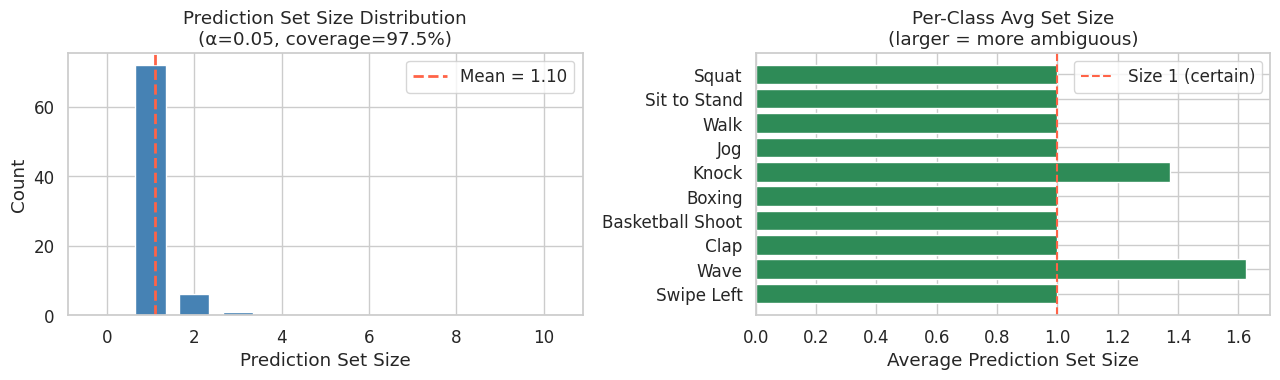


Note: classes with avg set size > 1 are ambiguous for the model.


In [26]:
# ── Visualisation: prediction set size distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of set sizes
ax = axes[0]
ax.hist(test_sizes, bins=range(0, NUM_CLASSES + 2), align='left',
        rwidth=0.7, color='steelblue', edgecolor='white')
ax.axvline(test_sizes.mean(), color='tomato', linestyle='--', linewidth=2,
           label=f'Mean = {test_sizes.mean():.2f}')
ax.set_xlabel('Prediction Set Size')
ax.set_ylabel('Count')
ax.set_title(f'Prediction Set Size Distribution\n(α={alpha}, coverage={test_cov*100:.1f}%)')
ax.legend()

# Right: per-class average set size (shows which classes are more ambiguous)
ax = axes[1]
per_class_sizes = [
    test_sizes[test_labels.numpy() == c].mean()
    if (test_labels.numpy() == c).any() else 0
    for c in range(NUM_CLASSES)
]
ax.barh(CLASS_NAMES, per_class_sizes, color='seagreen', edgecolor='white')
ax.set_xlabel('Average Prediction Set Size')
ax.set_title('Per-Class Avg Set Size\n(larger = more ambiguous)')
ax.axvline(1.0, color='tomato', linestyle='--', linewidth=1.5, label='Size 1 (certain)')
ax.legend()

plt.tight_layout()
plt.show()
print(f'\nNote: classes with avg set size > 1 are ambiguous for the model.')

In [27]:
# ── Per-class coverage analysis ───────────────────────────────────────────────
# CP guarantees *marginal* coverage (averaged over all samples).
# Conditional coverage (per class) may be lower for minority classes.

per_class_cov = []
for c in range(NUM_CLASSES):
    mask = test_labels.numpy() == c
    if mask.sum() == 0:
        per_class_cov.append(float('nan'))
        continue
    cov = sum(1 for s, y in zip(test_pred_sets, test_labels.numpy())
              if y == c and c in s) / mask.sum()
    per_class_cov.append(cov)

cov_df = pd.DataFrame({'Class': CLASS_NAMES, 'Coverage': per_class_cov,
                        'AvgSetSize': per_class_sizes})
print('Per-class conformal coverage (marginal guarantee: ≥ 95%):')
print(cov_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Per-class conformal coverage (marginal guarantee: ≥ 95%):
           Class  Coverage  AvgSetSize
      Swipe Left     1.000       1.000
            Wave     1.000       1.625
            Clap     1.000       1.000
Basketball Shoot     1.000       1.000
          Boxing     1.000       1.000
           Knock     0.750       1.375
             Jog     1.000       1.000
            Walk     1.000       1.000
    Sit to Stand     1.000       1.000
           Squat     1.000       1.000


## Alternative Confidence Methods (Theory)

Two well-known alternatives to Conformal Prediction:

### MC Dropout
MC Dropout approximates Bayesian inference by keeping dropout **active at test time** and performing $T$ forward passes. The empirical variance across passes estimates epistemic (model) uncertainty, and the mean softmax gives a calibrated probability estimate. While intuitive, MC Dropout requires $T$ times more compute and provides no formal coverage guarantee.

**Predictive mean** (approximates posterior predictive):
$$\bar{p}(y \mid x) = \frac{1}{T} \sum_{t=1}^{T} \hat{f}^{(t)}(x)_y$$

**Predictive uncertainty** (epistemic variance across $T$ passes):
$$\mathrm{Var}[y \mid x] = \frac{1}{T} \sum_{t=1}^{T} \hat{f}^{(t)}(x)_y^2 - \bar{p}(y \mid x)^2$$

where $\hat{f}^{(t)}(x)_y$ is the softmax probability for class $y$ on the $t$-th stochastic forward pass (with dropout active).

### Temperature Scaling
Temperature Scaling post-processes the logits by dividing by a learned scalar $T > 1$ before softmax, which *spreads* the distribution and reduces overconfidence. The temperature is found by minimizing NLL on a hold-out set. It is extremely cheap (one extra parameter) but calibrates only the average confidence level — it does not produce prediction sets and offers no distribution-free guarantees.

**Calibrated probability**:
$$\hat{p}(y \mid x) = \frac{\exp(z_y / T)}{\sum_{k=1}^{K} \exp(z_k / T)}$$

**Optimal temperature** found by minimizing NLL on a validation set:
$$T^* = \arg\min_{T > 0} \; -\frac{1}{n} \sum_{i=1}^{n} \log \hat{p}(y_i \mid x_i; T)$$

where $z_y$ are the pre-softmax logits and $K$ is the number of classes.

**Why Conformal Prediction is preferred here**: CP provides a *formal, finite-sample guarantee* that the prediction set contains the true label with at least $1-\alpha$ probability, regardless of the model architecture, data distribution, or sample size — something MC Dropout and Temperature Scaling cannot offer.


---
# Part 7: Out-of-Distribution (OOD) Detection

## Conformal Prediction as an OOD Signal

An immediate OOD indicator from Part 6: when the resulting **prediction set is empty**, it means *no class* had softmax probability above the threshold $1 - \hat{q}$. This happens precisely when the model is unconfident about every class simultaneously — a strong signal that the input does not resemble any in-distribution sample.

A **large prediction set** is another OOD signal: when many classes exceed the threshold, the model is hedging and assigning similar (low) confidence across them. In-distribution samples tend to yield small, focused prediction sets; a set containing most or all classes suggests the input may be OOD.

However, empty and large prediction sets are relatively rare for mildly OOD inputs (the model may still produce a low-confidence guess or a seemingly reasonable set). For more reliable OOD detection we use a dedicated VAE-based approach.

## VAE-based OOD Detection

**Key idea**: Train a Variational Autoencoder (VAE) to reconstruct the 640-d late-fusion feature vectors of **in-distribution** training samples. At test time, a high reconstruction error signals that the input's feature vector lies outside the learned ID manifold — i.e. the sample is OOD.

**Why use the fusion vector?**  
The 640-d bottleneck captures both modalities' learned representations and is much lower-dimensional than raw pixels/sensor signals. This makes the VAE compact and focused on task-relevant structure.

**OOD threshold**: Set to the **65th percentile** of reconstruction errors on the validation set. This means 35% of true ID samples may be falsely flagged, trading a small increase in false-positive rate for improved detection sensitivity on true OOD samples.

**OOD test samples**: Action classes *not* present in `SUBSET_ACTIONS` — same subjects and recording conditions as the training data, but unseen motion patterns. This is the hardest OOD scenario (covariate shift only in the action space).

In [28]:
# ── Load or train the FusionVAE ───────────────────────────────────────────────
vae_ckpt_path  = CHECKPOINTS_DIR / 'vae.pt'
vae_thresh_path = CHECKPOINTS_DIR / 'vae_threshold.json'
FUSION_DIM = VIDEO_FEAT_DIM + INERTIAL_FEAT_DIM  # 640

try:
    # ── Attempt to load pre-trained VAE ──
    vae_ckpt = torch.load(vae_ckpt_path, map_location=device, weights_only=False)
    hp = vae_ckpt['hparams']
    vae = FusionVAE(
        input_dim=hp['input_dim'],
        latent_dim=hp['latent_dim'],
        hidden_dim=hp['hidden_dim'],
        beta=hp['beta'],
    ).to(device)
    vae.load_state_dict(vae_ckpt['model_state_dict'])
    vae_train_losses = vae_ckpt.get('train_losses', [])

    with open(vae_thresh_path) as f:
        thresh_data = json.load(f)
    ood_threshold = thresh_data['ood_threshold']

    print(f'Loaded VAE from {vae_ckpt_path}')
    print(f'  Hparams: {hp}')
    print(f'  OOD threshold: {ood_threshold:.4f}')

except (FileNotFoundError, KeyError, RuntimeError) as e:
    # ── Fallback: train the VAE inline ──
    print(f'VAE checkpoint not found ({e}), training from scratch...')

    VAE_LATENT_DIM = 64
    VAE_HIDDEN_DIM = 256
    VAE_BETA = 1.0
    VAE_LR = 1e-3
    VAE_EPOCHS = 60
    VAE_BATCH_SIZE = 32

    vae = FusionVAE(input_dim=FUSION_DIM, latent_dim=VAE_LATENT_DIM,
                    hidden_dim=VAE_HIDDEN_DIM, beta=VAE_BETA).to(device)
    optimizer_vae = torch.optim.Adam(vae.parameters(), lr=VAE_LR, weight_decay=1e-5)
    scheduler_vae = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vae, T_max=VAE_EPOCHS)

    train_vae_ds = TensorDataset(train_vecs)
    train_vae_loader = DataLoader(train_vae_ds, batch_size=VAE_BATCH_SIZE, shuffle=True)

    vae_train_losses = []
    for epoch in range(VAE_EPOCHS):
        vae.train()
        epoch_loss = 0.0
        for (x_batch,) in train_vae_loader:
            x_batch = x_batch.to(device)
            x_hat, mu, log_var = vae(x_batch)
            loss, _, _ = vae.loss(x_batch, x_hat, mu, log_var)
            optimizer_vae.zero_grad()
            loss.backward()
            optimizer_vae.step()
            epoch_loss += loss.item()
        scheduler_vae.step()
        avg = epoch_loss / len(train_vae_loader)
        vae_train_losses.append(avg)
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{VAE_EPOCHS}  loss={avg:.4f}')

    # Compute OOD threshold on val set
    val_errors_thresh = vae.reconstruction_error(val_vecs.to(device)).cpu().numpy()
    ood_threshold = float(np.percentile(val_errors_thresh, 65))
    print(f'  OOD threshold: {ood_threshold:.4f}')

Loaded VAE from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/vae.pt
  Hparams: {'input_dim': 640, 'latent_dim': 64, 'hidden_dim': 256, 'beta': 1.0}
  OOD threshold: 0.1133


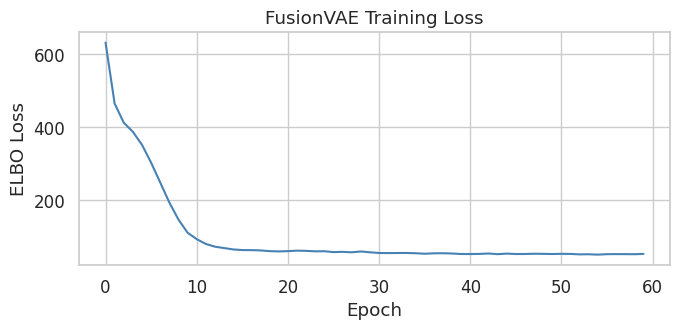

In [29]:
# ── VAE training curve ────────────────────────────────────────────────────────
if vae_train_losses:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(vae_train_losses, color='steelblue')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('ELBO Loss')
    ax.set_title('FusionVAE Training Loss')
    plt.tight_layout()
    plt.show()

In [30]:
# ── Compute reconstruction errors for all splits ──────────────────────────────
vae.eval()
val_errors  = vae.reconstruction_error(val_vecs.to(device)).cpu().numpy()
test_errors = vae.reconstruction_error(test_vecs.to(device)).cpu().numpy()
ood_errors  = vae.reconstruction_error(ood_vecs.to(device)).cpu().numpy() \
              if len(ood_vecs) > 0 else np.array([])

# ID test samples flagged as OOD (false positives)
id_ood_mask = test_errors > ood_threshold
# True OOD samples correctly flagged (true positives)
ood_ood_mask = ood_errors > ood_threshold if len(ood_errors) > 0 else np.array([])

print('=== VAE OOD Detection Results ===')
print(f'OOD threshold: {ood_threshold:.4f}')
print(f'Val   errors — mean: {val_errors.mean():.4f}  std: {val_errors.std():.4f}')
print(f'Test  errors — mean: {test_errors.mean():.4f}  std: {test_errors.std():.4f}')
if len(ood_errors) > 0:
    print(f'OOD   errors — mean: {ood_errors.mean():.4f}  std: {ood_errors.std():.4f}')
print(f'\nID test samples flagged as OOD: {id_ood_mask.sum()} / {len(test_errors)} '
      f'({100*id_ood_mask.mean():.1f}%)  ← false positives')
if len(ood_ood_mask) > 0:
    print(f'True OOD samples detected:      {ood_ood_mask.sum()} / {len(ood_errors)} '
          f'({100*ood_ood_mask.mean():.1f}%)  ← true positive rate')

=== VAE OOD Detection Results ===
OOD threshold: 0.1133
Val   errors — mean: 0.0942  std: 0.0473
Test  errors — mean: 0.0427  std: 0.0295
OOD   errors — mean: 0.0956  std: 0.0481

ID test samples flagged as OOD: 2 / 79 (2.5%)  ← false positives
True OOD samples detected:      29 / 136 (21.3%)  ← true positive rate


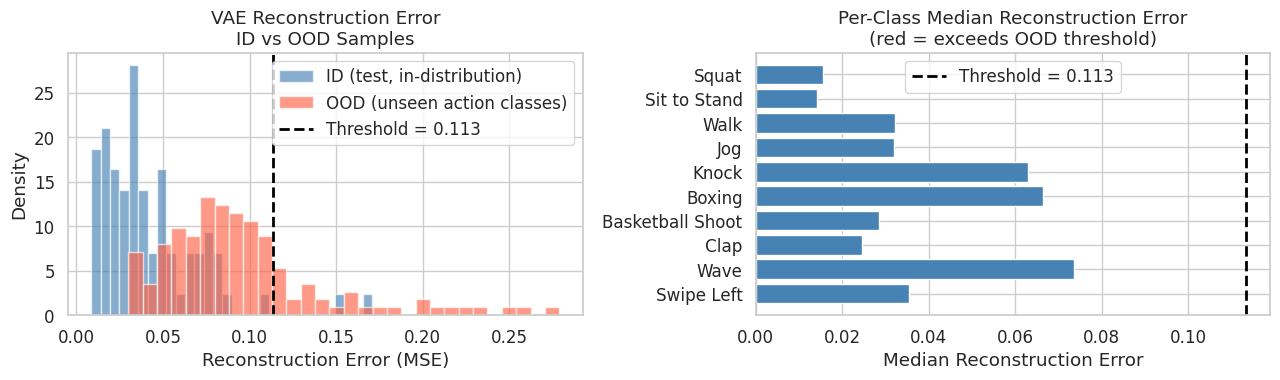

In [31]:
# ── Visualisation: Reconstruction error distributions ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overlapping histograms of ID test vs OOD
ax = axes[0]
ax.hist(test_errors, bins=30, alpha=0.65, label='ID (test, in-distribution)', color='steelblue', density=True)
if len(ood_errors) > 0:
    ax.hist(ood_errors, bins=30, alpha=0.65, label='OOD (unseen action classes)', color='tomato', density=True)
ax.axvline(ood_threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {ood_threshold:.3f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('VAE Reconstruction Error\nID vs OOD Samples')
ax.legend()

# Right: per-class median error for ID test samples
ax = axes[1]
per_class_err = [
    np.median(test_errors[test_labels.numpy() == c])
    if (test_labels.numpy() == c).any() else 0
    for c in range(NUM_CLASSES)
]
colors = ['tomato' if e > ood_threshold else 'steelblue' for e in per_class_err]
ax.barh(CLASS_NAMES, per_class_err, color=colors, edgecolor='white')
ax.axvline(ood_threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {ood_threshold:.3f}')
ax.set_xlabel('Median Reconstruction Error')
ax.set_title('Per-Class Median Reconstruction Error\n(red = exceeds OOD threshold)')
ax.legend()

plt.tight_layout()
plt.show()

In [32]:
# ── Compute CP set sizes for OOD samples ─────────────────────────────────────
# Pass OOD fusion vectors through the fusion classifier head to get softmax
# probabilities, then apply the conformal threshold already calibrated on ID data.
# Larger prediction sets or empty sets signal that CP also detects OOD inputs.

if len(ood_vecs) > 0:
    ood_probs = get_softmax_probs(ood_vecs)          # (n_ood, num_classes)
    ood_pred_sets = predict_set(ood_probs, q_hat)    # list of lists
    ood_cp_sizes = set_sizes(ood_pred_sets)          # (n_ood,)
    ood_cp_ood_flags = ood_flags(ood_pred_sets)      # True = empty set
else:
    ood_cp_sizes = np.array([])
    ood_cp_ood_flags = np.array([])

# ── Success cases: ID samples with lowest reconstruction error ─────────────────
# These are samples the VAE understands best — low error, small CP set, high confidence.
n_show = 5
success_idx = np.argsort(test_errors)[:n_show]  # lowest error = most ID

success_df = pd.DataFrame({
    'Sample': success_idx,
    'True Class': [CLASS_NAMES[test_labels[i].item()] for i in success_idx],
    'Recon Error': test_errors[success_idx].round(4),
    'VAE OOD Flag': test_errors[success_idx] > ood_threshold,
    'CP Set Size': set_sizes(test_pred_sets)[success_idx],
})
print(f'=== Success Cases: {n_show} ID samples with LOWEST reconstruction error ===')
print('(Expected: low error, not flagged, CP set size = 1)')
print(success_df.to_string(index=False))

=== Success Cases: 5 ID samples with LOWEST reconstruction error ===
(Expected: low error, not flagged, CP set size = 1)
 Sample   True Class  Recon Error  VAE OOD Flag  CP Set Size
     65 Sit to Stand       0.0087         False            1
     67 Sit to Stand       0.0093         False            1
     16         Clap       0.0109         False            1
     64 Sit to Stand       0.0117         False            1
     69 Sit to Stand       0.0130         False            1


In [33]:
# ── False positives: highest-error ID samples ────────────────────────────────
# ID samples the VAE found hardest to reconstruct.
# After moving to the 90th-pct threshold some of these will be flagged as OOD.
high_err_idx = np.argsort(test_errors)[-n_show:][::-1]
high_err_df = pd.DataFrame({
    'Sample': high_err_idx,
    'True Class': [CLASS_NAMES[test_labels[i].item()] for i in high_err_idx],
    'Recon Error': test_errors[high_err_idx].round(4),
    'VAE OOD Flag': test_errors[high_err_idx] > ood_threshold,
    'CP Set Size': set_sizes(test_pred_sets)[high_err_idx],
})
print(f'=== False Positives: {n_show} ID samples with HIGHEST reconstruction error ===')
print('(ID samples — VAE or CP may incorrectly flag some as OOD)')
print(high_err_df.to_string(index=False))

# ── True OOD samples: sorted by reconstruction error (highest first = easy to detect) ──
if len(ood_errors) > 0:
    print(f'\n=== True OOD Samples — easiest to detect (highest recon error) ===')
    print('(Both VAE and CP should flag these — large error AND large/empty CP set)')
    ood_sorted_idx = np.argsort(ood_errors)[::-1][:n_show]
    ood_easy_df = pd.DataFrame({
        'Sample': ood_sorted_idx,
        'Recon Error': ood_errors[ood_sorted_idx].round(4),
        'VAE OOD Flag': ood_errors[ood_sorted_idx] > ood_threshold,
        'CP Set Size': ood_cp_sizes[ood_sorted_idx].astype(int),
        'CP Empty Set': ood_cp_ood_flags[ood_sorted_idx],
    })
    print(ood_easy_df.to_string(index=False))

    # ── FAILURES: OOD samples that neither method flags ───────────────────────
    # These are the hardest cases — the OOD motion is similar enough to ID
    # that both the VAE and CP fail to detect it.
    print(f'\n=== FAILURES: OOD samples NOT detected by VAE or CP ===')
    print('These are the true failures: unseen actions the system treats as in-distribution.')
    neither_mask = (~(ood_errors > ood_threshold)) & (~ood_cp_ood_flags)
    if neither_mask.sum() > 0:
        fail_idx = np.where(neither_mask)[0][:n_show]
        fail_df = pd.DataFrame({
            'Sample': fail_idx,
            'Recon Error': ood_errors[fail_idx].round(4),
            'VAE OOD Flag': ood_errors[fail_idx] > ood_threshold,
            'CP Set Size': ood_cp_sizes[fail_idx].astype(int),
            'CP Empty Set': ood_cp_ood_flags[fail_idx],
        })
        print(fail_df.to_string(index=False))
        print(f'\nTotal undetected OOD samples: {neither_mask.sum()} / {len(ood_errors)} '
              f'({100*neither_mask.mean():.1f}%)')
        print('Reason: these OOD actions produce fusion vectors close to the ID manifold,')
        print('and the model\'s softmax still assigns probability to some ID class.')
    else:
        print('All OOD samples were detected by at least one method!')

=== False Positives: 5 ID samples with HIGHEST reconstruction error ===
(ID samples — VAE or CP may incorrectly flag some as OOD)
 Sample True Class  Recon Error  VAE OOD Flag  CP Set Size
     37     Boxing       0.1708          True            1
     38     Boxing       0.1525          True            1
      9       Wave       0.1091         False            2
     36     Boxing       0.0865         False            1
     39     Boxing       0.0835         False            1

=== True OOD Samples — easiest to detect (highest recon error) ===
(Both VAE and CP should flag these — large error AND large/empty CP set)
 Sample  Recon Error  VAE OOD Flag  CP Set Size  CP Empty Set
     65       0.2788          True            3         False
     74       0.2595          True            2         False
     77       0.2535          True            4         False
     75       0.2338          True            1         False
     67       0.2254          True            4         False

==

In [34]:
# ── OOD signal comparison: ID test set (false-positive rate) ─────────────────
cp_ood = test_ood_flags          # empty prediction set from Part 6
vae_ood = id_ood_mask            # VAE reconstruction error above threshold
combined_ood = cp_ood | vae_ood  # flag if either method triggers

print('=== OOD Signal on ID Test Set (false-positive rate — lower is better) ===')
print(f'CP  large/empty-set flags: {cp_ood.sum()} / {len(cp_ood)} ({100*cp_ood.mean():.1f}%)')
print(f'VAE recon-error flags:     {vae_ood.sum()} / {len(vae_ood)} ({100*vae_ood.mean():.1f}%)')
print(f'Combined (CP OR VAE):      {combined_ood.sum()} / {len(combined_ood)} ({100*combined_ood.mean():.1f}%)')

# ── OOD signal on true OOD samples (true-positive rate) ──────────────────────
if len(ood_errors) > 0:
    ood_vae_flag = ood_errors > ood_threshold         # VAE catches this OOD sample
    ood_cp_flag  = ood_cp_ood_flags                   # CP empty-set on this OOD sample
    ood_cp_large = ood_cp_sizes > 1                   # CP large-set (ambiguous) on OOD
    ood_either   = ood_vae_flag | ood_cp_flag         # caught by at least one method
    ood_any_signal = ood_vae_flag | ood_cp_large      # caught by VAE OR large CP set

    print(f'\n=== OOD Signal on TRUE OOD Samples (true-positive rate — higher is better) ===')
    print(f'VAE flags (recon error > threshold): {ood_vae_flag.sum()} / {len(ood_errors)} '
          f'({100*ood_vae_flag.mean():.1f}%)')
    print(f'CP empty set (size = 0):             {ood_cp_flag.sum()} / {len(ood_errors)} '
          f'({100*ood_cp_flag.mean():.1f}%)')
    print(f'CP large set (size > 1):             {ood_cp_large.sum()} / {len(ood_errors)} '
          f'({100*ood_cp_large.mean():.1f}%)')
    print(f'Detected by VAE OR CP empty-set:     {ood_either.sum()} / {len(ood_errors)} '
          f'({100*ood_either.mean():.1f}%)')
    print(f'Detected by VAE OR large CP set:     {ood_any_signal.sum()} / {len(ood_errors)} '
          f'({100*ood_any_signal.mean():.1f}%)')
    print(f'\nCP avg set size on OOD samples: {ood_cp_sizes.mean():.2f} '
          f'(compare: {set_sizes(test_pred_sets).mean():.2f} on ID test samples)')
    print('Larger CP sets on OOD samples confirm that CP detects distributional shift')
    print('as model uncertainty — even when the set is not fully empty.')

=== OOD Signal on ID Test Set (false-positive rate — lower is better) ===
CP  large/empty-set flags: 0 / 79 (0.0%)
VAE recon-error flags:     2 / 79 (2.5%)
Combined (CP OR VAE):      2 / 79 (2.5%)

=== OOD Signal on TRUE OOD Samples (true-positive rate — higher is better) ===
VAE flags (recon error > threshold): 29 / 136 (21.3%)
CP empty set (size = 0):             0 / 136 (0.0%)
CP large set (size > 1):             70 / 136 (51.5%)
Detected by VAE OR CP empty-set:     29 / 136 (21.3%)
Detected by VAE OR large CP set:     83 / 136 (61.0%)

CP avg set size on OOD samples: 1.96 (compare: 1.10 on ID test samples)
Larger CP sets on OOD samples confirm that CP detects distributional shift
as model uncertainty — even when the set is not fully empty.


## System Response Strategy for OOD Detection

When the system flags an input as OOD (via VAE reconstruction error, empty CP set, or both), the following graduated response strategy should be applied:

### 1. Fail-safe Mechanism
The primary obligation when OOD is detected is to **refuse to produce an untrustworthy prediction** and fall back to a safe default:
- Return a special `"UNKNOWN / OOD"` label rather than the argmax of the softmax.
- If the system is embedded in a control loop (e.g. robotics, fall detection), revert to the last known-good state or trigger a conservative action (e.g. stop, alert, remain stationary).
- Emit a machine-readable confidence flag alongside every prediction so downstream consumers can apply their own policy.

### 2. Logging for Active Learning
Every OOD-flagged sample should be stored in a dedicated buffer for later inspection:
- Log the raw sensor/video data, the fusion vector, the reconstruction error, and the CP prediction set size.
- Periodically review the buffer to identify recurring OOD patterns — these often represent new action classes, sensor drift, or deployment-site covariate shift.
- Once human labels are assigned, the flagged samples can be used to expand `SUBSET_ACTIONS` and retrain the system (active learning loop), incrementally improving coverage without a full re-collect.

### 3. Human-in-the-Loop Intervention
For high-stakes decisions (medical monitoring, elder care, industrial safety), OOD detection should trigger an immediate escalation:
- Send a real-time alert to a human supervisor with a summary: reconstruction error, CP set size, most probable class (even if below threshold), and a sample from the video/sensor stream.
- The human reviews, provides a label or a "safe to ignore" signal, and the outcome is logged.
- Track inter-rater agreement and model disagreement rates to audit system reliability over time.

This three-tier strategy — **refuse → log → escalate** — ensures the system degrades gracefully under distribution shift rather than silently producing wrong predictions with false confidence.